In [1]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LogNorm
from matplotlib.transforms import ScaledTranslation
from matplotlib import ticker

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cmocean

In [2]:
def setup_axes(ax):
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
    ax.coastlines(resolution='110m', color='black', lw=2)
    ax.set_ylabel('latitude')
    ax.set_xlabel('longitude')


def label_ax(ax, label, position='top', fontsize=16):
    if position == 'inside':
        ax.annotate(
            label,
            xy=(0, 1), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',
            fontsize=fontsize, verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='1.', edgecolor='k', pad=3.0))
    elif position == 'top':
        ax.text(
            0.0, 1.0, label, transform=(
                ax.transAxes + ScaledTranslation(7/72, +3/72, fig.dpi_scale_trans)),
            fontsize=fontsize, va='bottom', fontfamily='sans-serif')

# Load Data

In [3]:
data_fold = '../final_data'
LEAD = 3
ds_attrs = xr.merge([
    xr.open_dataset(f'{data_fold}/spatial_attrs_r3_location.nc').sel(lead=LEAD).mean('month'),
    xr.open_dataset(f'{data_fold}/spatial_attrs_r3_ratios.nc').sel(lead=LEAD).mean('month')])
ds_attrs_random = xr.open_dataset(f'{data_fold}/spatial_attrs_random_03L.nc').mean('month')
ds = xr.open_dataset(f'{data_fold}/leadtime_attrs_r3.nc')
ds_random = xr.open_dataset(f'{data_fold}/leadtime_attrs_random.nc')

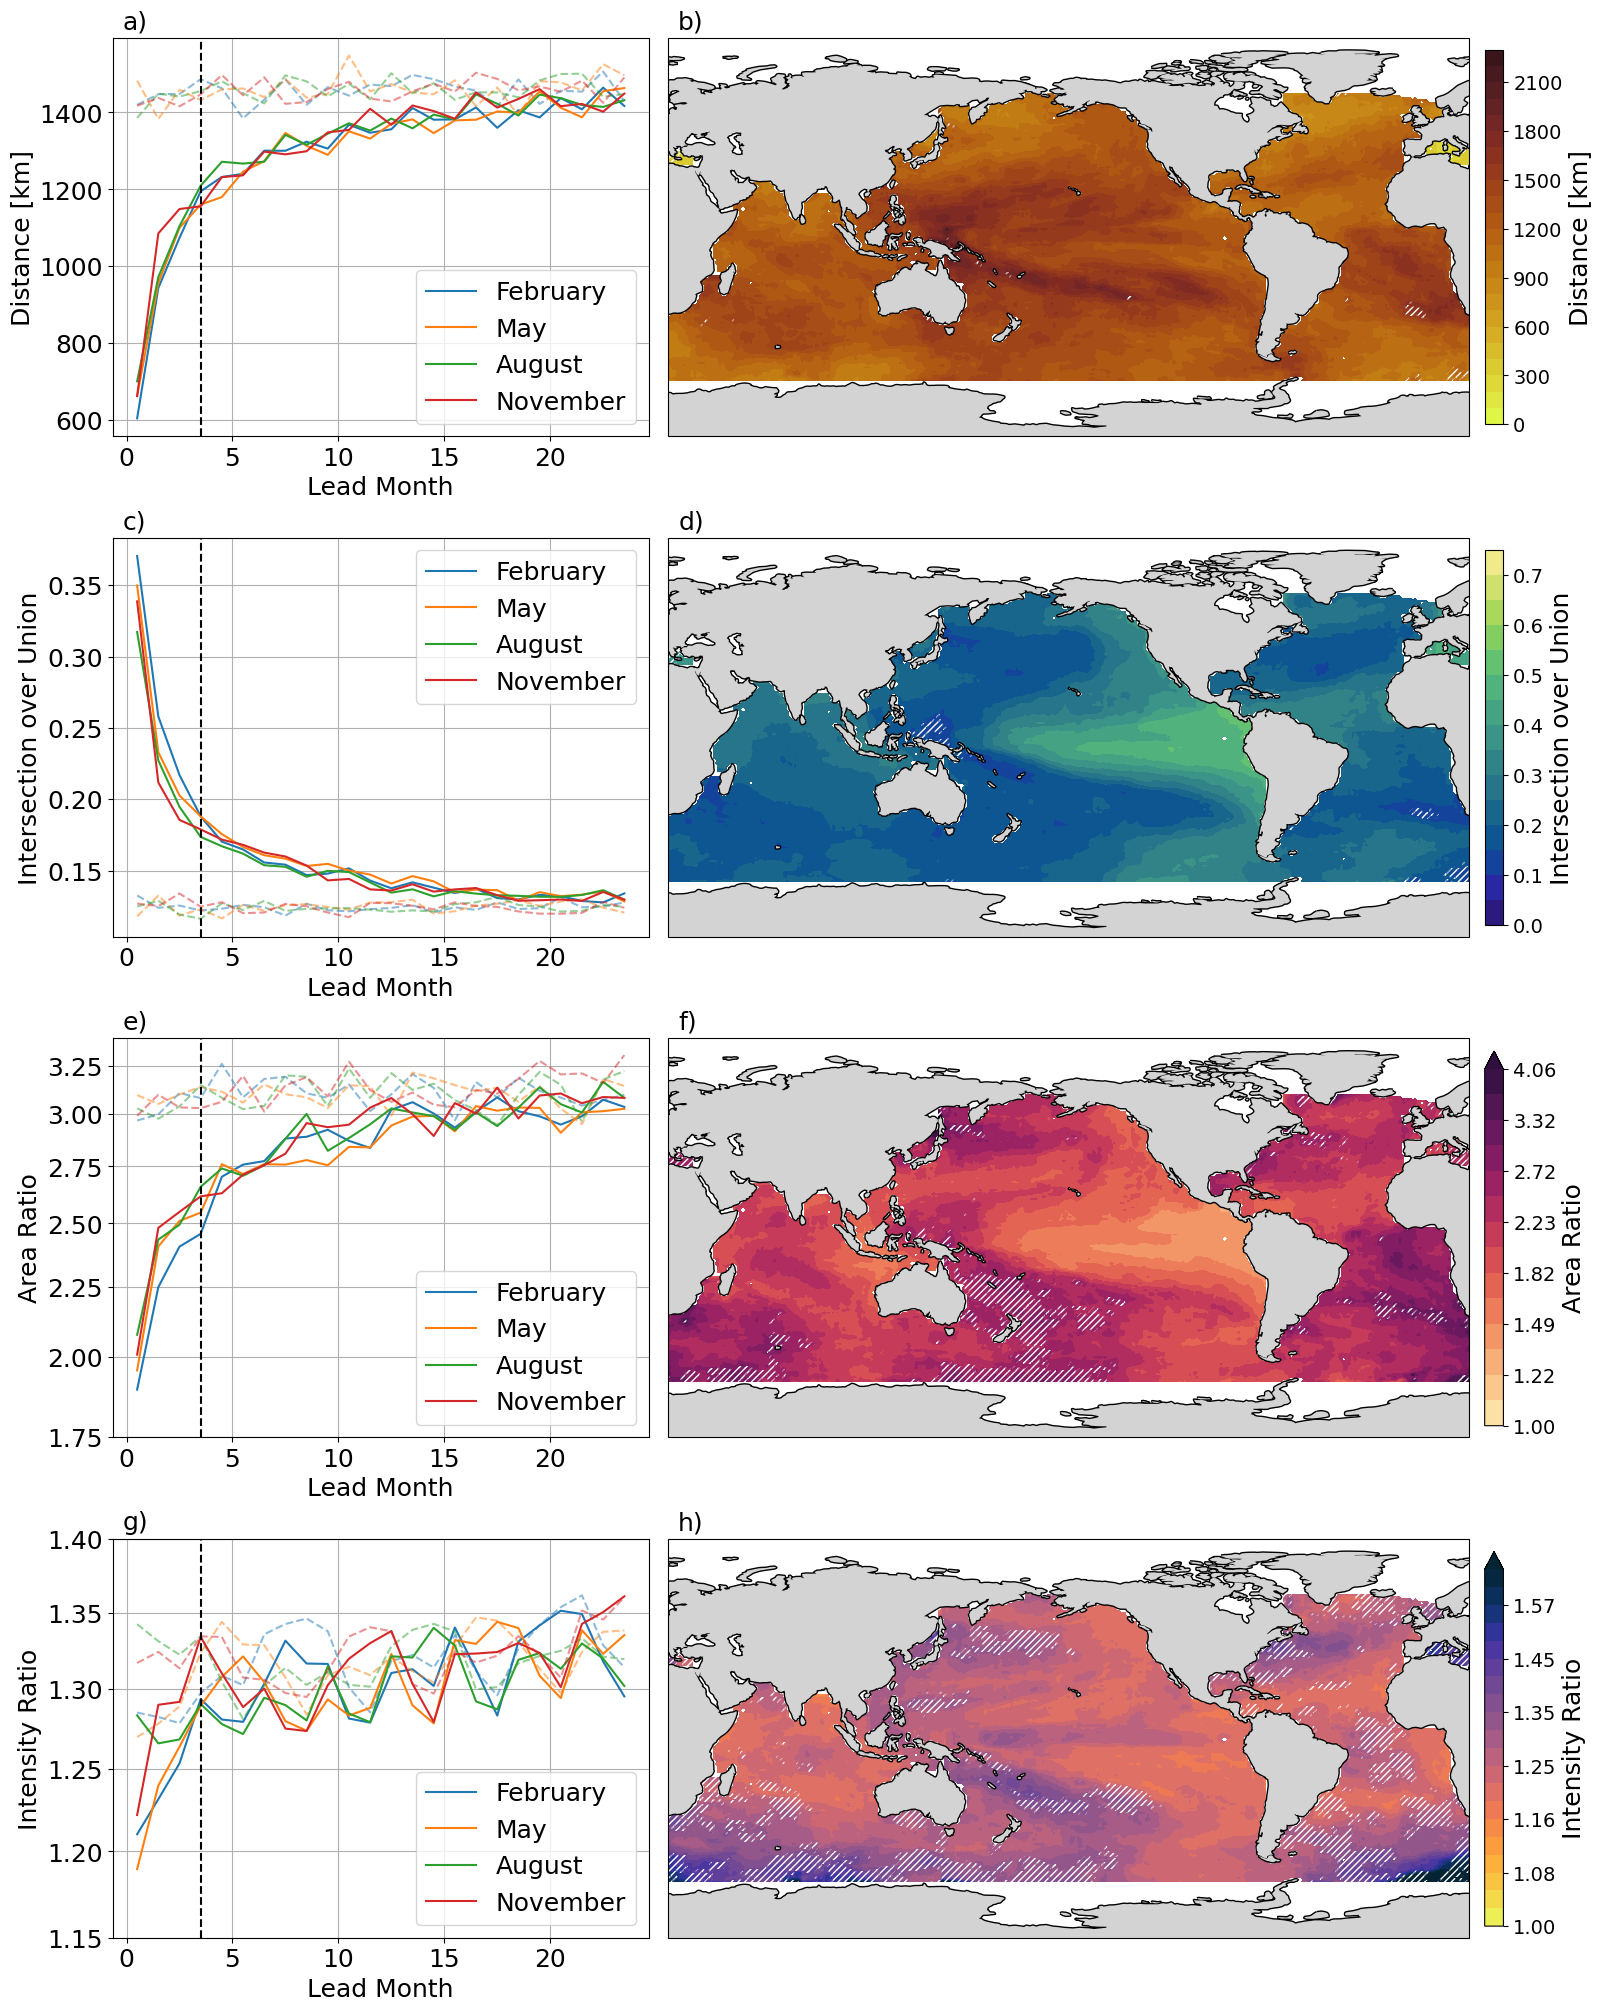

In [4]:
colors = plt.cm.tab10
month_names = ['February', 'May', 'August', 'November']
data = [
    ds['CENTROID_DIST_KM'],
    ds['INTERSECTION_OVER_UNION'],
    np.exp(ds['ABS_LOG_AREA_RATIO']),
    np.exp(ds['ABS_LOG_INTENSITY_50_RATIO'])
]
data_random = [
    ds_random['CENTROID_DIST_KM'],
    ds_random['INTERSECTION_OVER_UNION'],
    np.exp(ds_random['ABS_LOG_AREA_RATIO']),
    np.exp(ds_random['ABS_LOG_INTENSITY_50_RATIO'])
]
data1 = [
    ds_attrs['CENTROID_DIST_KM'],
    ds_attrs['INTERSECTION_OVER_UNION'],
    np.exp(ds_attrs['ABS_LOG_AREA_RATIO']),
    np.exp(ds_attrs['ABS_LOG_INTENSITY_50_RATIO'])
]
data1_insignificant = [
    xr.where(ds_attrs['CENTROID_DIST_KM'] > ds_attrs_random['CENTROID_DIST_KM'], 1, 0),
    xr.where(ds_attrs['INTERSECTION_OVER_UNION'] < ds_attrs_random['INTERSECTION_OVER_UNION'], 1, 0),
    xr.where(np.exp(ds_attrs['ABS_LOG_AREA_RATIO']) > np.exp(ds_attrs_random['ABS_LOG_AREA_RATIO']), 1, 0),
    xr.where(np.exp(ds_attrs['ABS_LOG_INTENSITY_50_RATIO']) > np.exp(ds_attrs_random['ABS_LOG_INTENSITY_50_RATIO']), 1, 0)
]

ylabels = ['Distance [km]', 'Intersection over Union', 'Area Ratio', 'Intensity Ratio']
clabels = ylabels
labels_left = ['a)', 'c)', 'e)', 'g)']
labels_right = ['b)', 'd)', 'f)', 'h)']
cmaps = [cmocean.cm.solar_r, cmocean.cm.haline, cmocean.cm.matter, cmocean.cm.thermal_r]
levs_vals = [np.arange(24)*100, np.linspace(0, 0.75, 16), np.exp(np.linspace(0, 1.4, 15)), np.exp(np.linspace(0, 0.5, 21))]
extends = [None, None, 'max', 'max']
norms = [None, None, LogNorm(), LogNorm()]
formatter = [None, None, ticker.FormatStrFormatter('%.2f'), ticker.FormatStrFormatter('%.2f')]
ticks2 = np.linspace(1.75, 3.25, 7)
ticks3 = np.linspace(1.15, 1.4, 6)

label_pos = 'top'
textsize=18
labelsize = 18
cbarnumbersize = 14
cbartextsize = 18
plt.rcParams['hatch.linewidth'] = 1
plt.rcParams['hatch.color'] = 'w'

fig, axs = plt.subplots(4, 2, figsize=(16, 20), width_ratios=[1, 1.5], layout='compressed')

for i in range(4):
    for j in range(4):
        axs[i, 0].plot(np.arange(0, 24)+0.5, data[i].isel(month=j),
                       label=month_names[j], c=colors(j))
        axs[i, 0].plot(np.arange(0, 24)+0.5, data_random[i].isel(month=j),
                       label=None, c=colors(j),
                       ls='--', alpha=0.5)
    axs[i, 0].set_xlabel('Lead Month', fontsize=textsize)
    axs[i, 0].set_ylabel(ylabels[i], fontsize=textsize)
    axs[i, 0].tick_params(labelsize=textsize)
    axs[i, 0].grid()
    axs[i, 0].axvline(LEAD+0.5, c='k', ls='--')
    label_ax(axs[i, 0], labels_left[i], 'top', fontsize=labelsize)

    axs[i, 1].remove()
    ax = fig.add_subplot(4, 2, 2*i+2, projection=ccrs.PlateCarree(200))
    setup_axes(ax)
    im = ax.contourf(ds_attrs.lon, ds_attrs.lat, data1[i], transform=ccrs.PlateCarree(), cmap=cmaps[i], levels=levs_vals[i], extend=extends[i], norm=norms[i])
    im_insig = ax.contourf(ds_attrs.lon, ds_attrs.lat, data1_insignificant[i], 3, transform=ccrs.PlateCarree(), hatches=['', '/////'], alpha=0, colors='w')
    cbar = plt.colorbar(im, ax=ax, fraction=0.0233, pad=0.02, format=formatter[i])
    cbar.set_label(label=clabels[i], size=cbartextsize)
    cbar.ax.tick_params(labelsize=cbarnumbersize)
    label_ax(ax, labels_right[i], label_pos, fontsize=labelsize)

axs[2, 0].set_yscale('log')
axs[3, 0].set_yscale('log')
axs[2, 0].set_yticks(ticks2, labels=[f'{t:.2f}' for t in ticks2])
axs[3, 0].set_yticks(ticks3, labels=[f'{t:.2f}' for t in ticks3])

axs[0, 0].legend(loc=4, fontsize=textsize)
axs[1, 0].legend(loc=1, fontsize=textsize)
axs[2, 0].legend(loc=4, fontsize=textsize)
axs[3, 0].legend(loc=4, fontsize=textsize)

# plt.savefig('../final_figs/fig3.pdf')
plt.savefig('../final_figs/fig3.jpg', dpi=600)
plt.show()